In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from enum import Enum

from mesa import Model, Agent
from mesa.experimental.cell_space import OrthogonalMooreGrid, FixedAgent
from mesa.datacollection import DataCollector


from mesa.visualization import draw_space


class StateOfTree(Enum):
    HEALTHY = 0
    BURNING = 1 
    DEAD = 2
    
# Added counter to track number of healthy, burning, dead trees in the forrest, over time. This is useful for plotting the results of the model and understanding how the fire spreads over time.    
def count_healthy(model):
    return sum(1 for agent in model.agents if agent.state == StateOfTree.HEALTHY)

def count_burning(model):
    return sum(1 for agent in model.agents if agent.state == StateOfTree.BURNING)

def count_dead(model):
    return sum(1 for agent in model.agents if agent.state == StateOfTree.DEAD)


    
class ForestFire(Model):


    def __init__(self, height=20, width=20, density=0.9, seed=None):
        super().__init__(seed=seed)
        self.space = OrthogonalMooreGrid((height, width), torus=False, capacity=1, random=seed)
        
        for cell in self.space.all_cells:
            if self.random.random() < density:
                # Create a tree
                tree = Tree(self, cell)
                
        self.datacollector = DataCollector(
            model_reporters={
                "healthy": count_healthy,
                "burning": count_burning,
                "dead": count_dead,
            }
        )
        self.datacollector.collect(self)        

    def step(self):
        """
        Run one step of the model.
        """
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)


class Tree(FixedAgent):


    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell
        self.state = StateOfTree.HEALTHY
        
    def step(self):
        if self.state == StateOfTree.BURNING:
            for neighbor in self.cell.neighborhood.agents:
                if neighbor.state == StateOfTree.HEALTHY:
                    neighbor.state = StateOfTree.BURNING
            # implicit assumption of 1 tick for burning down
            self.state = StateOfTree.DEAD


def agent_portrayal(agent):
    colors = {StateOfTree.HEALTHY: "tab:green",
              StateOfTree.BURNING: "tab:orange",
              StateOfTree.DEAD: "tab:brown"}
    return {"color":colors[agent.state], "size":14}

def plot_model(model):
    sns.set_style('white')
    fig, ax = plt.subplots()
    draw_space(model.space, agent_portrayal=agent_portrayal, ax=ax, draw_grid=False)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    return fig

#New plotting tool to see behvaiour and fire spread over time


def plot_state_counts(model):
    df = model.datacollector.get_model_vars_dataframe()
    
    fig, ax = plt.subplots()
    df.plot(ax=ax, color=["tab:green", "tab:orange", "tab:brown"])
    ax.set_xlabel("Step")
    ax.set_ylabel("Number of trees")
    ax.set_title("Forest fire dynamics")
    ax.legend(title="State")
    sns.despine()
    return fig
    
    

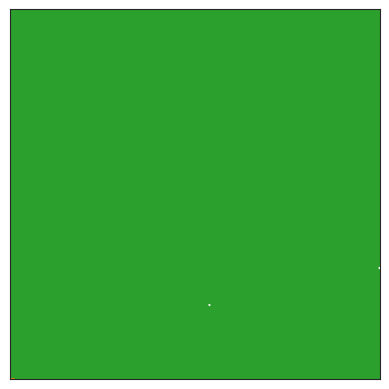

In [4]:
model = ForestFire(100, 100, seed=12345)
model.agents[0].state = StateOfTree.BURNING
plot_model(model)
plt.show()

 ### 14. How would you approach implementing hexagonal tiling?
 
to introduce a hexagonal tiling into the model, we are fortunate ot be able to use an already exsiting spatial layout frm Mesa, called "HexGrid". To implement this layout, in the model all we have to change are hte imports to make sure we download the HexGrid instead of the POrthogonalMooreGrid, and then change the line where we initialize the space to use HexGrid instead. No other functions or methods need to be changed, as the rest of the code is agnostic to the type of grid being used.

### 15. How would you approach implementing wind and wind direction that affects the spread of the fire?

- make sure torrus is set to false as we want to be able to select direction and not spread in all directions
- add a new parameter to the model called "wind_direction" that can take on values such N, NW, W, SW, S, SE, E, NE(for Moore/HEX Grid)
- in the step function of the Tree agent, when we check the neighbors, we can add a condition to check if the neighbor is in the direction of the wind. If it is, then we can increase the probability of it catching fire. For example, if the wind is blowing to the east, then we can increase the probability of a tree catching fire if it is to the east of a burning tree, and decrease the probability if it is to the west. 
- we check if the neighbour is in the direction of the wind because the model assigns coordinates to each cell, so if we define each direction as a set of coordinates, we can easily implement direction

# Initializing a new plot for Moore to see behvaiour of fire over time

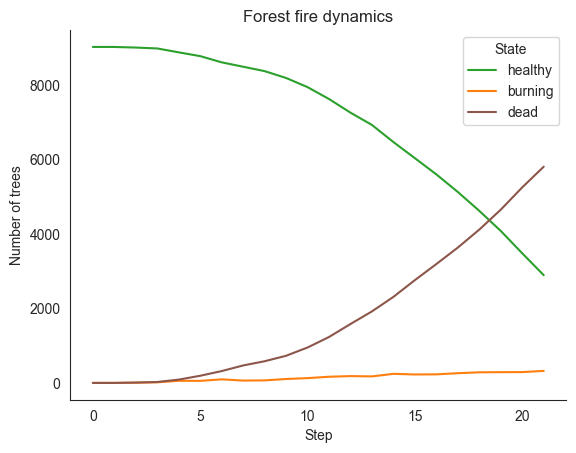

In [8]:
model = ForestFire(100, 100, seed=12345)
model.agents[0].state = StateOfTree.BURNING
model.datacollector.collect(model)

for _ in range(20):
    model.step()

plot_state_counts(model)
plt.show()

# Implementing for von Neumman

Needed modifications: 
- import the VonNeumannGrid instead of the OrthogonalMooreGrid
- change the line where we initialize the space to use VonNeumannGrid instead of Orthogonal
- everything else can stay the same as the rest of the code is agnostic to the type of grid being used. 

*An important remark would be to create that creating a paramter for the type of grid to use in the model would be a good idea, as it would allow us to easily switch between different types of grids without having to change the code in multiple places. This would make the model more flexible and easier to maintain.*

In [13]:
from mesa.experimental.cell_space import (
    OrthogonalMooreGrid,
    OrthogonalVonNeumannGrid,
    FixedAgent,
)

class ForestFireNeighbour(Model):

    def __init__(self, height=20, width=20, density=0.9, neighborhood="moore", seed=None):
        super().__init__(seed=seed)

        self.height = height
        self.width = width
        self.density = density
        self.neighborhood = neighborhood.lower()

        if self.neighborhood == "moore":
            grid_cls = OrthogonalMooreGrid
        elif self.neighborhood in ["vonneumann", "von_neumann", "vn"]:
            grid_cls = OrthogonalVonNeumannGrid
        else:
            raise ValueError("neighborhood must be 'moore' or 'vonneumann'")

        self.space = grid_cls((height, width), torus=False, capacity=1, random=self.random)

        for cell in self.space.all_cells:
            if self.random.random() < density:
                Tree(self, cell)


        self.datacollector = DataCollector(
            model_reporters={
                "healthy": count_healthy,
                "burning": count_burning,
                "dead": count_dead,
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """
        Run one step of the model.
        """
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)


In [19]:
n_steps=100

moore_model = ForestFireNeighbour(100, 100, density=0.9, neighborhood="moore", seed=12345)
vn_model = ForestFireNeighbour(100, 100, density=0.9, neighborhood="vonneumann", seed=12345)

# ignite one tree in each model
moore_model.agents[0].state = StateOfTree.BURNING
vn_model.agents[0].state = StateOfTree.BURNING

# recollect after ignition so the starting point is correct
moore_model.datacollector.collect(moore_model)
vn_model.datacollector.collect(vn_model)

# run both models for the same number of steps
for _ in range(n_steps):
    moore_model.step()
    vn_model.step()

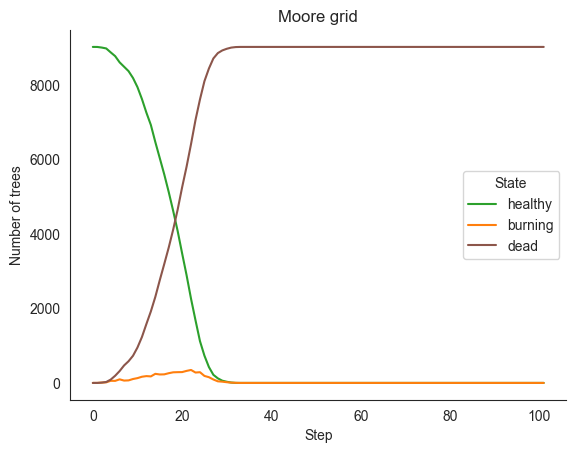

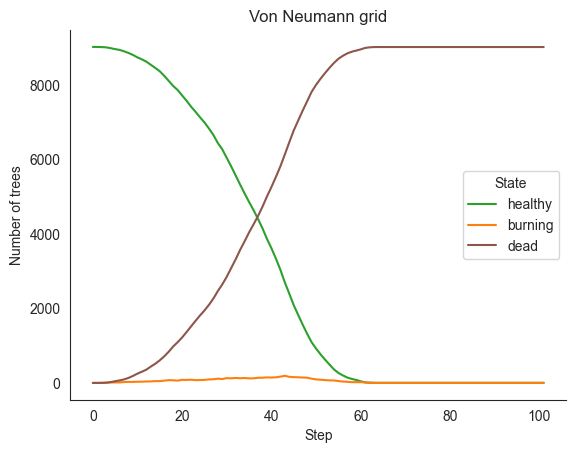

In [20]:
plot_state_counts(moore_model)
plt.title("Moore grid")
plt.show()

plot_state_counts(vn_model)
plt.title("Von Neumann grid")
plt.show()

Rate of death (slope of the line) much higher in Moore than von Neumann as expected, because Moore has 8 neighbours and Von Neumann has 4, so the fire can spread more quickly in the Moore grid. This is because in the Moore grid, a burning tree can ignite any of its 8 neighbors, while in the Von Neumann grid, a burning tree can only ignite its 4 orthogonal neighbors. Therefore, we would expect to see a faster spread of the fire and a higher rate of death in the Moore grid compared to the Von Neumann grid.


In [35]:
from mesa.experimental.cell_space import (
    OrthogonalMooreGrid,
    OrthogonalVonNeumannGrid,
    FixedAgent,
)

class ForrestNeighbourRadius(Model):

    def __init__(self, height=20, width=20, density=0.9, radius =1, neighborhood="moore", seed=None):
        super().__init__(seed=seed)
        
        #initiate radius as a model attribute so we can use it in the step function of the Tree agent
        self.radius = radius
        self.height = height
        self.width = width
        self.density = density
        self.neighborhood = neighborhood.lower()

        if self.neighborhood == "moore":
            grid_cls = OrthogonalMooreGrid
        elif self.neighborhood in ["vonneumann", "von_neumann", "vn"]:
            grid_cls = OrthogonalVonNeumannGrid
        else:
            raise ValueError("neighborhood must be 'moore' or 'vonneumann'")

        self.space = grid_cls((height, width), torus=False, capacity=1, random=self.random)

        for cell in self.space.all_cells:
            if self.random.random() < density:
                TreeRadius(self, cell)


        self.datacollector = DataCollector(
            model_reporters={
                "healthy": count_healthy,
                "burning": count_burning,
                "dead": count_dead,
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """
        Run one step of the model.
        """
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)
        
        
class TreeRadius(FixedAgent):
    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell
        self.state = StateOfTree.HEALTHY

    def step(self):
        if self.state == StateOfTree.BURNING:
            for neighbor in self.cell.get_neighborhood(radius=self.model.radius).agents:
                if neighbor.state == StateOfTree.HEALTHY:
                    neighbor.state = StateOfTree.BURNING
            self.state = StateOfTree.DEAD
    



In [36]:
model_r1 = ForrestNeighbourRadius(100, 100, density=0.9, radius=1, seed=12345)
model_r2 = ForrestNeighbourRadius(100, 100, density=0.9, radius=2, seed=12345)
print(type(model_r2.agents[0]).__name__, model_r2.radius)

model_r3 = ForrestNeighbourRadius(100, 100, density=0.9, radius=3, seed=12345)

# ignite one tree in each model
model_r1.agents[0].state = StateOfTree.BURNING
model_r2.agents[0].state = StateOfTree.BURNING
model_r3.agents[0].state = StateOfTree.BURNING

n_steps = 30
for _ in range(n_steps):
    model_r1.step()
    model_r2.step()
    model_r3.step()

# recollect after ignition so the starting point is correct
model_r1.datacollector.collect(model_r1)
model_r2.datacollector.collect(model_r2)
model_r3.datacollector.collect(model_r3)


TreeRadius 2


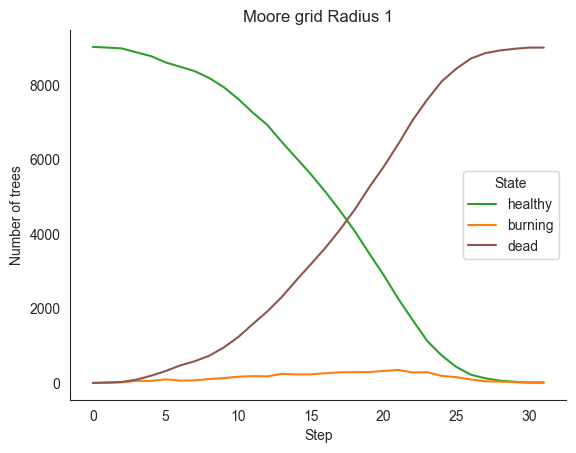

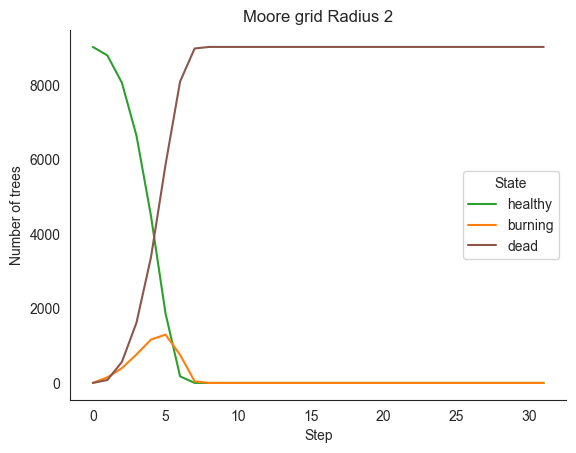

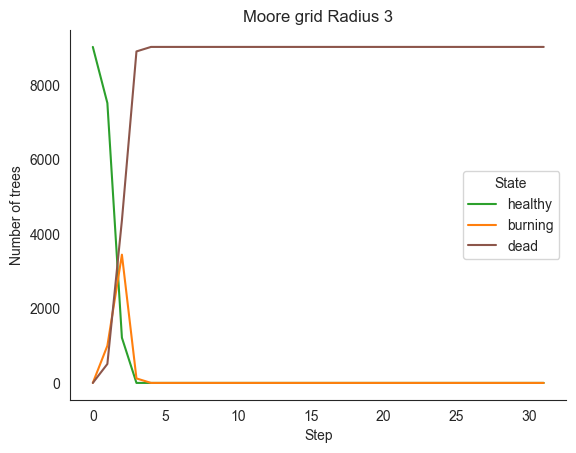

In [37]:
plot_state_counts(model_r1)
plt.title("Moore grid Radius 1")
plt.show()

plot_state_counts(model_r2)
plt.title("Moore grid Radius 2")
plt.show()

plot_state_counts(model_r3)
plt.title("Moore grid Radius 3")
plt.show()

 As expected, increasing the Moore neighborhood radius makes the fire spread much faster.  
With `radius = 1`, fire propagation is local and gradual.  
With `radius = 2` and especially `radius = 3`, each burning tree can ignite a much larger set of neighbors in one step, creating a cascade effect.  
This causes the `healthy` curve to drop quickly and the `dead` curve to rise sharply, so the forest burns down almost immediately at higher radius.